In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
wr.filterwarnings('ignore')

In [2]:
df=pd.read_csv('data.csv')

In [4]:
df.head(10)

,customer_id,total_quantity,total_spent,total_orders,category_prefer,recency,average_order_value,cluster
0,40873,26,12955.0655,7,Home Decor,102,1850.723643,Best Customers
1,27889,23,12462.8120,6,Electronics,137,2077.135333,Best Customers
2,15933,24,11917.5365,6,Electronics,17,1986.256083,Best Customers
3,34270,25,11654.9850,5,Accessories,13,2330.997000,Best Customers
4,24933,19,11362.3775,6,Footwear,110,1893.729583,Best Customers
5,28605,24,11282.7165,7,Fashion,174,1611.816643,Best Customers
6,16198,22,10957.5540,5,Beauty,237,2191.510800,Best Customers
7,33354,24,10696.6490,6,Electronics,196,1782.774833,Best Customers
8,43578,17,10245.5450,4,Accessories,258,2561.386250,Best Customers
9,15572,19,10154.7240,5,Accessories,69,2030.944800,Best Customers


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31154 entries, 0 to 31153
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          31154 non-null  int64  
 1   total_quantity       31154 non-null  int64  
 2   total_spent          31154 non-null  float64
 3   total_orders         31154 non-null  int64  
 4   category_prefer      31154 non-null  object 
 5   recency              31154 non-null  int64  
 6   average_order_value  31154 non-null  float64
 7   cluster              31154 non-null  object 
dtypes: float64(2), int64(4), object(2)
memory usage: 1.9+ MB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,31154.0,29983.218592,11552.356719,10000.000,19958.50000,29977.50000,39969.750000,49999.0000
total_quantity,31154.0,5.796174,3.692589,1.000,3.00000,5.00000,8.000000,28.0000
total_spent,31154.0,1914.551593,1524.748823,3.534,720.96675,1570.02100,2731.504500,12955.0655
total_orders,31154.0,1.925916,1.034863,1.000,1.00000,2.00000,2.000000,8.0000
recency,31154.0,341.122520,246.755569,0.000,129.00000,296.00000,524.000000,899.0000
average_order_value,31154.0,993.369982,656.356499,3.534,494.39775,882.51975,1356.203937,3999.5000


In [8]:
df.drop('customer_id',axis=1,inplace=True)

In [9]:
df.head()

,total_quantity,total_spent,total_orders,category_prefer,recency,average_order_value,cluster
0,26,12955.0655,7,Home Decor,102,1850.723643,Best Customers
1,23,12462.8120,6,Electronics,137,2077.135333,Best Customers
2,24,11917.5365,6,Electronics,17,1986.256083,Best Customers
3,25,11654.9850,5,Accessories,13,2330.997000,Best Customers
4,19,11362.3775,6,Footwear,110,1893.729583,Best Customers


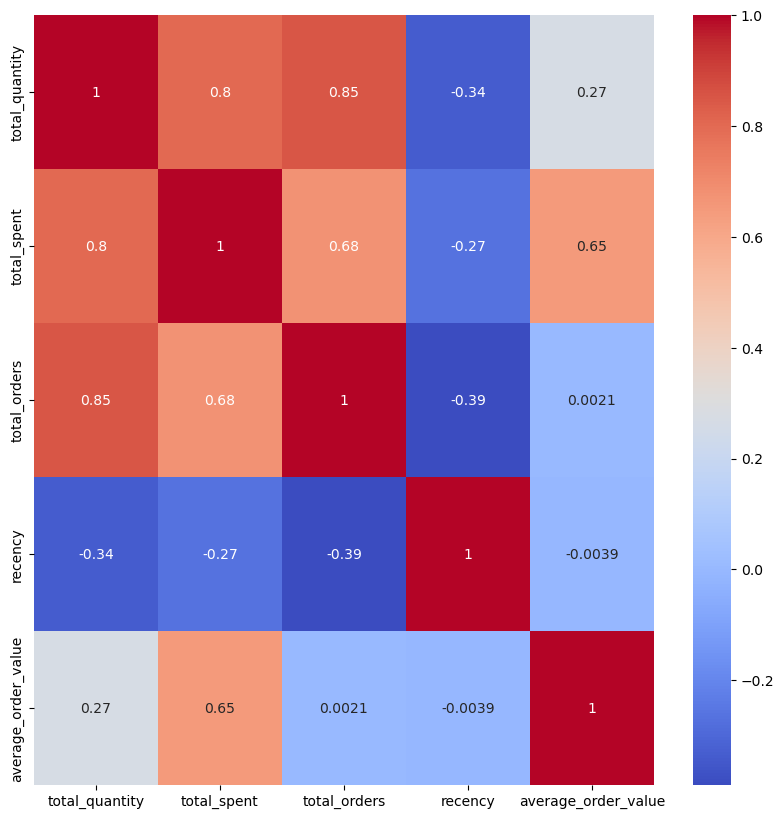

In [10]:
corr=df.corr(numeric_only=True)
plt.figure(figsize=(10,10))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

In [11]:
df.isnull().sum()

total_quantity         0
total_spent            0
total_orders           0
category_prefer        0
recency                0
average_order_value    0
cluster                0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [54]:
target_dis=df['cluster'].value_counts()

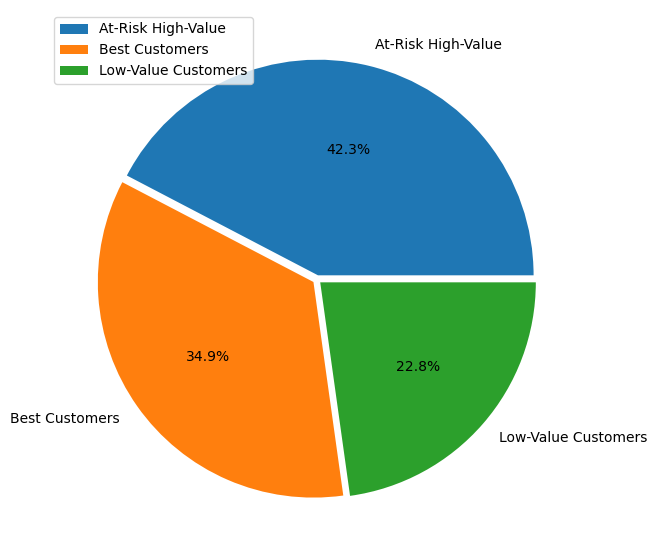

In [69]:
plt.figure(figsize=(9,7))
plt.pie(target_dis,explode=(0.02,0.02,0.02),labels=target_dis.index,autopct='%1.1f%%')
plt.legend()
plt.show()

In [13]:
x=df.drop('cluster',axis=1)
y=df['cluster']

In [19]:
num_cols=x.select_dtypes('number').columns
cat_cols=x.select_dtypes('object').columns

In [20]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [21]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
y_train=encoder.fit_transform(y_train)
y_test=encoder.transform(y_test)

In [23]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
ct=ColumnTransformer(transformers=[('oe',OneHotEncoder(handle_unknown='ignore'),cat_cols),
                                  ('st',StandardScaler(),num_cols)])
x_train=ct.fit_transform(x_train)
x_test=ct.transform(x_test)

In [24]:
x_train

array([[ 0.        ,  0.        ,  0.        , ..., -0.89361491,
        -1.05546457, -0.86793514],
       [ 0.        ,  1.        ,  0.        , ..., -0.89361491,
         1.4950973 ,  0.36825049],
       [ 0.        ,  0.        ,  0.        , ..., -0.89361491,
         0.78142657, -0.08585773],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  2.00092623,
         0.81386615,  0.60910818],
       [ 1.        ,  0.        ,  0.        , ..., -0.89361491,
         0.41648131,  0.83987243],
       [ 0.        ,  0.        ,  0.        , ...,  0.07123214,
         0.01098658, -0.98272554]])

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_curve,auc,roc_auc_score
lr=LogisticRegression()
lr.fit(x_train,y_train)

LogisticRegression()

accuracy =  0.9772107205905954
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      2608
           1       0.98      0.98      0.98      2221
           2       0.98      0.99      0.98      1402

    accuracy                           0.98      6231
   macro avg       0.98      0.98      0.98      6231
weighted avg       0.98      0.98      0.98      6231



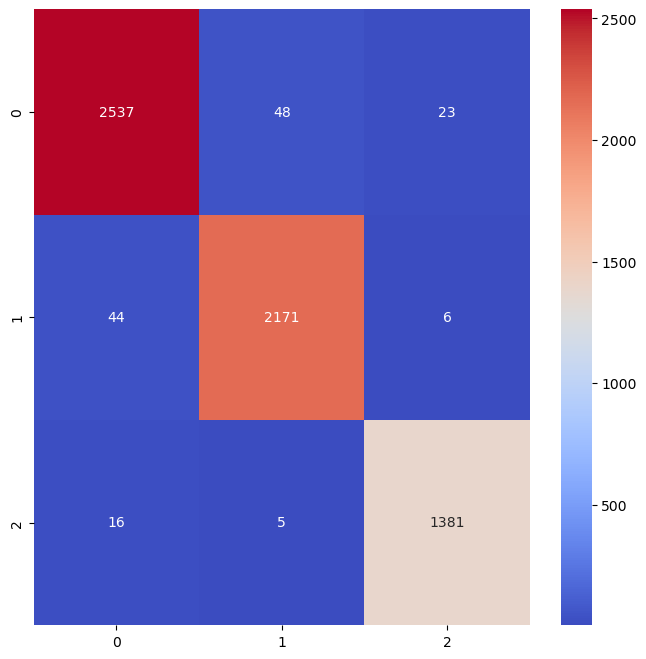

In [38]:
y_pred=lr.predict(x_test)
print('accuracy = ',accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8,8))
sns.heatmap(cm,annot=True,cmap='coolwarm',fmt='.0f',)
plt.show()

In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import GridSearchCV
rf=RandomForestClassifier(random_state=42,n_jobs=-1)
param_grid={'n_estimators':[100,200,300],
           'max_depth':[1,3,5,7],
           'min_samples_split':[1,3,5],
           'min_samples_leaf':[1,3,5]}
grid=GridSearchCV(estimator=rf,param_grid=param_grid,cv=5)
grid.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             param_grid={'max_depth': [1, 3, 5, 7],
                         'min_samples_leaf': [1, 3, 5],
                         'min_samples_split': [1, 3, 5],
                         'n_estimators': [100, 200, 300]})

In [43]:
best_model=grid.best_estimator_
y_pred=best_model.predict(x_test)
print('accuracy = ',accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))


accuracy =  0.9723960840956508
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      2608
           1       0.99      0.96      0.97      2221
           2       0.98      0.97      0.98      1402

    accuracy                           0.97      6231
   macro avg       0.98      0.97      0.97      6231
weighted avg       0.97      0.97      0.97      6231



In [49]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
xgboost=XGBClassifier()
param_grid={'n_estimators':[100,200,300],
           'max_depth':[1,3,5],
           'min_samples_split':[1,3,5]}
grid=GridSearchCV(estimator=xgboost,param_grid=param_grid,cv=5)
grid.fit(x_train,y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'max_depth': [1, 3, 5], 'min_samples_split': [1, 3, 5],
                         'n_estimators': [100, 200, 300]})

accuracy =  0.9935804846734072
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2608
           1       0.99      0.99      0.99      2221
           2       1.00      0.99      0.99      1402

    accuracy                           0.99      6231
   macro avg       0.99      0.99      0.99      6231
weighted avg       0.99      0.99      0.99      6231



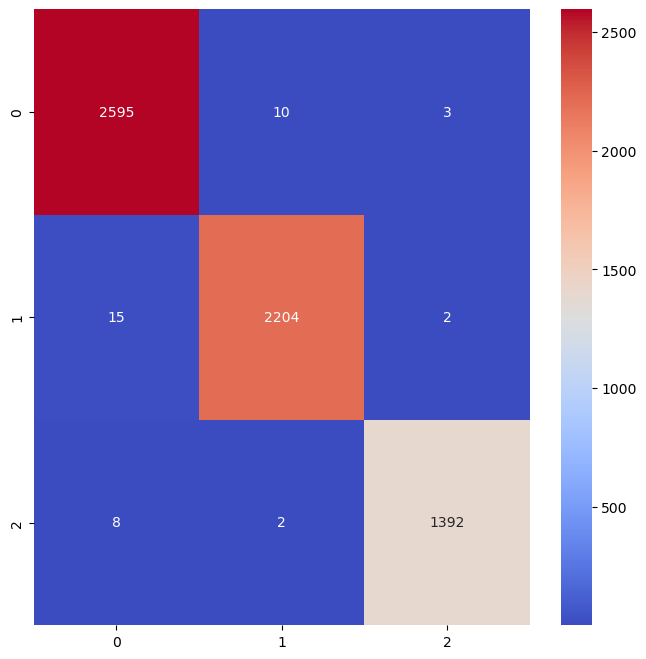

In [53]:
xgboost_best=grid.best_estimator_
y_pred=xgboost_best.predict(x_test)
print('accuracy = ',accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8,8))
sns.heatmap(cm,annot=True,cmap='coolwarm',fmt='.0f',)
plt.show()

In [51]:
from sklearn.ensemble import VotingClassifier
v_c=VotingClassifier(estimators=[('lr',lr),('rf',best_model),('xgboost',xgboost_best)])
v_c.fit(x_train,y_train)

VotingClassifier(estimators=[('lr', LogisticRegression()),
                             ('rf',
                              RandomForestClassifier(max_depth=7,
                                                     min_samples_split=3,
                                                     n_estimators=200,
                                                     n_jobs=-1,
                                                     random_state=42)),
                             ('xgboost',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categ...
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=3,
                                            max_leaves=None,
                                            min_child_weight=None,
                                            min_samples_split=1, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=300, n_jobs=None, ...))])

In [52]:
y_pred=v_c.predict(x_test)
print('accuracy = ',accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))


accuracy =  0.9874819451131439
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      2608
           1       0.99      0.98      0.99      2221
           2       0.99      0.99      0.99      1402

    accuracy                           0.99      6231
   macro avg       0.99      0.99      0.99      6231
weighted avg       0.99      0.99      0.99      6231




best model is XGboost 